# Lab 12: K-Means Clustering — Customer Segmentation

**Objective:** Apply K-Means clustering (unsupervised learning) on a customer marketing dataset to discover meaningful customer segments based on income and spending behaviour.

**Dataset:** `customer_segmentation.csv` — 2240 customers, 29 features including demographics, spending amounts across product categories, and campaign responses.


In [2]:
# ─── Cell 1: Import all required libraries ────────────────────────────────
# pandas  → data manipulation and loading CSV
# numpy   → numerical operations
# matplotlib / seaborn → data visualisation
# KMeans  → the clustering algorithm (from scikit-learn)
# StandardScaler → feature scaling (so income & spending are on same scale)
# silhouette_score → metric to evaluate cluster quality

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Make plots render inline and look clean
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [3]:
# ─── Cell 2: Load the dataset ─────────────────────────────────────────────
# read_csv() loads the CSV file into a DataFrame
# We copy the original so we never lose the raw data

data = pd.read_csv("customer_segmentation.csv")   # ← update path if needed
df   = data.copy()                                  # working copy

print(f"Dataset shape: {df.shape}")          # rows × columns
print("\nFirst 5 rows:")
df.head()


Dataset shape: (2240, 29)

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# ─── Cell 3: Dataset information — column names, data types, memory ────────
# .info() reveals dtypes and how many non-null values exist per column
# This helps spot columns we need to clean or encode

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
# ─── Cell 4: Descriptive statistics ───────────────────────────────────────
# .describe() shows count, mean, std, min, quartiles, max for numeric cols
# Key things to notice:
#   - Income has a wide range → needs scaling
#   - Spending columns (MntWines etc.) are heavily right-skewed
#   - Year_Birth tells us customer age (2024 - Year_Birth)

df.describe().T          # .T transposes so each feature is a row — easier to read


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [6]:
# ─── Cell 5: Check & handle missing values ────────────────────────────────
# Only the 'Income' column has 24 missing values (≈ 1% of data)
# Strategy: fill with the median — robust to outliers compared to mean

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing Income with the median income
df['Income'] = df['Income'].fillna(df['Income'].median())

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")


Missing values per column:
Income    24
dtype: int64

Missing values after imputation: 0


In [7]:
# ─── Cell 6: Feature engineering ─────────────────────────────────────────
# Create new meaningful features to enrich the clustering:
#   Age         → current age calculated from birth year
#   TotalSpend  → sum of all product spending columns
#   TotalKids   → kids + teenagers at home (proxy for family obligations)
#   NumChildren is kept as TotalKids for clarity

# Reference year (approximate data collection year)
REFERENCE_YEAR = 2014

df['Age']        = REFERENCE_YEAR - df['Year_Birth']
df['TotalSpend'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])
df['TotalKids']  = df['Kidhome'] + df['Teenhome']

print("New features added: Age, TotalSpend, TotalKids")
print(df[['Age', 'TotalSpend', 'TotalKids']].describe().T)


New features added: Age, TotalSpend, TotalKids
             count        mean         std   min    25%    50%     75%     max
Age         2240.0   45.194196   11.984069  18.0  37.00   44.0    55.0   121.0
TotalSpend  2240.0  605.798214  602.249288   5.0  68.75  396.0  1045.5  2525.0
TotalKids   2240.0    0.950446    0.751803   0.0   0.00    1.0     1.0     3.0


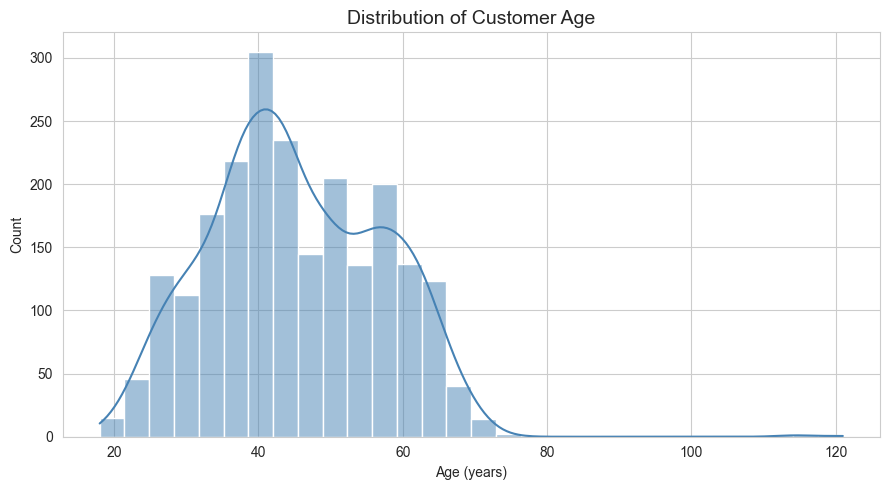

Mean age: 45.2  |  Median age: 44.0


In [8]:
# ─── Cell 7: EDA — Age distribution ──────────────────────────────────────
# A histogram shows how customers are spread across age groups.
# Insight: majority of customers are middle-aged (35-65).

plt.figure(figsize=(9, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Customer Age', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Mean age: {df['Age'].mean():.1f}  |  Median age: {df['Age'].median():.1f}")


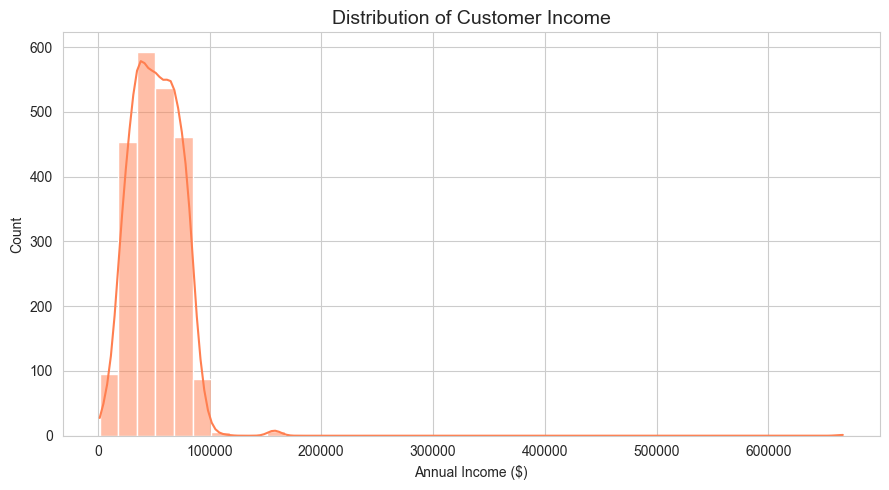

Customers with income > 200k: 1
Dataset size after removing outliers: 2239


In [9]:
# ─── Cell 8: EDA — Income distribution ───────────────────────────────────
# Right-skewed income distribution is typical in consumer datasets.
# Very high-income outliers (>200k) exist — noted for potential removal.

plt.figure(figsize=(9, 5))
sns.histplot(df['Income'], bins=40, kde=True, color='coral')
plt.title('Distribution of Customer Income', fontsize=14)
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Remove extreme outliers (income > 200,000 — likely data entry errors)
print(f"Customers with income > 200k: {(df['Income'] > 200000).sum()}")
df = df[df['Income'] < 200000].copy()
print(f"Dataset size after removing outliers: {len(df)}")


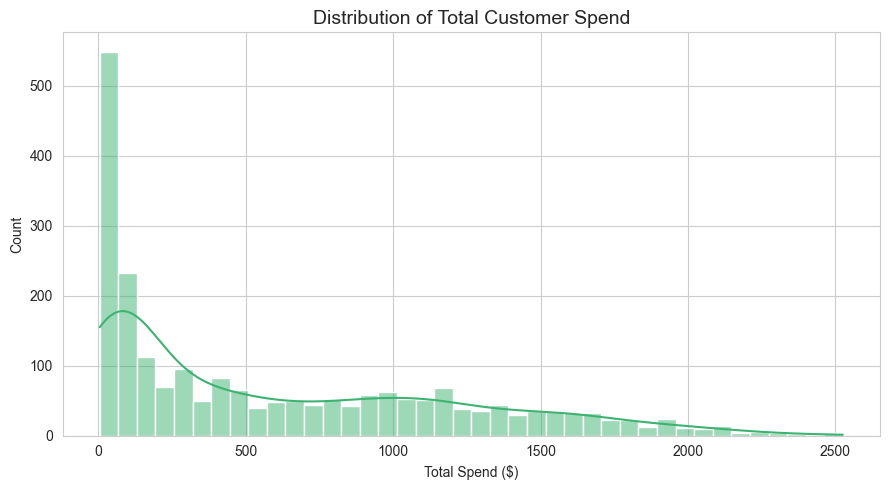

In [10]:
# ─── Cell 9: EDA — Total Spend distribution ───────────────────────────────
# Total spend per customer reveals two broad groups:
#   - Low spenders (< $500) — likely budget-conscious / low income
#   - High spenders (> $1000) — premium / loyal customers

plt.figure(figsize=(9, 5))
sns.histplot(df['TotalSpend'], bins=40, kde=True, color='mediumseagreen')
plt.title('Distribution of Total Customer Spend', fontsize=14)
plt.xlabel('Total Spend ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


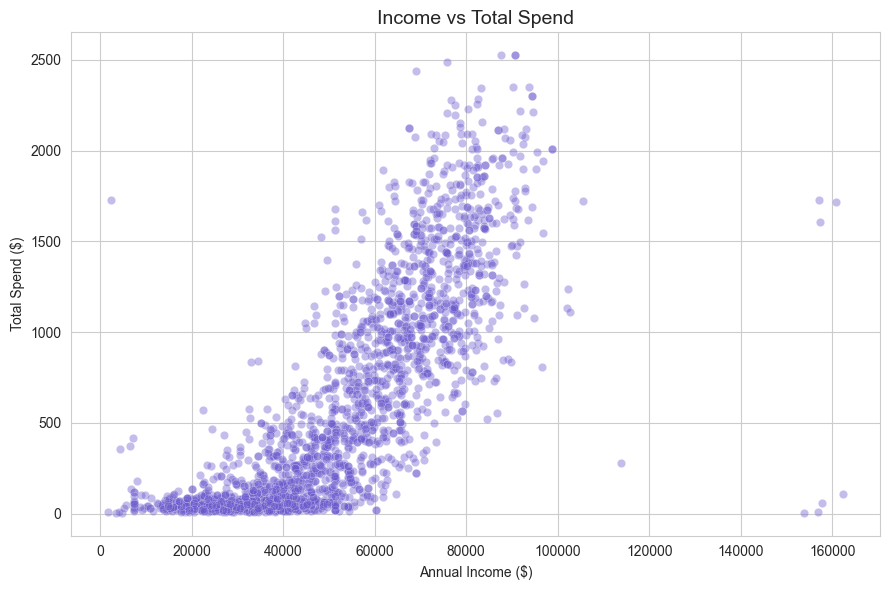

Pearson correlation (Income ↔ TotalSpend): 0.789


In [11]:
# ─── Cell 10: EDA — Income vs Total Spend scatter plot ───────────────────
# Strong positive correlation: higher income → higher spending.
# This confirms Income & TotalSpend are good features for clustering.

plt.figure(figsize=(9, 6))
plt.scatter(df['Income'], df['TotalSpend'], alpha=0.4, color='slateblue', edgecolors='white', linewidths=0.3)
plt.title('Income vs Total Spend', fontsize=14)
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.show()

corr = df['Income'].corr(df['TotalSpend'])
print(f"Pearson correlation (Income ↔ TotalSpend): {corr:.3f}")


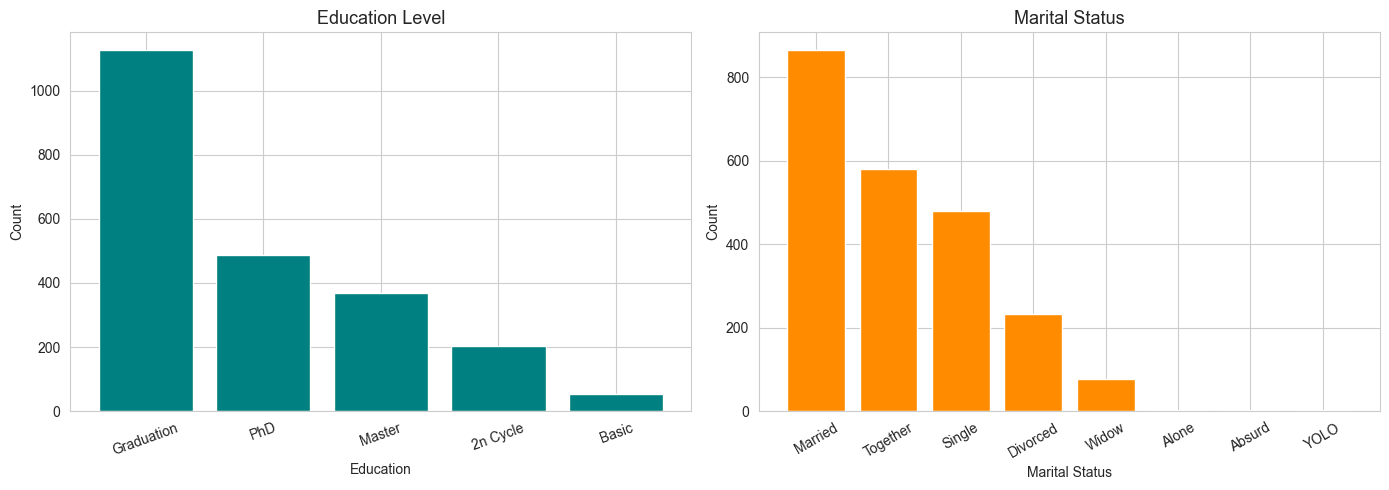

In [12]:
# ─── Cell 11: EDA — Categorical features (Education & Marital Status) ─────
# Bar charts for categorical columns reveal demographic composition.
# Insight: Most customers are Graduates; most are in a relationship.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Education
edu_counts = df['Education'].value_counts()
axes[0].bar(edu_counts.index, edu_counts.values, color='teal')
axes[0].set_title('Education Level', fontsize=13)
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Marital Status
ms_counts = df['Marital_Status'].value_counts()
axes[1].bar(ms_counts.index, ms_counts.values, color='darkorange')
axes[1].set_title('Marital Status', fontsize=13)
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


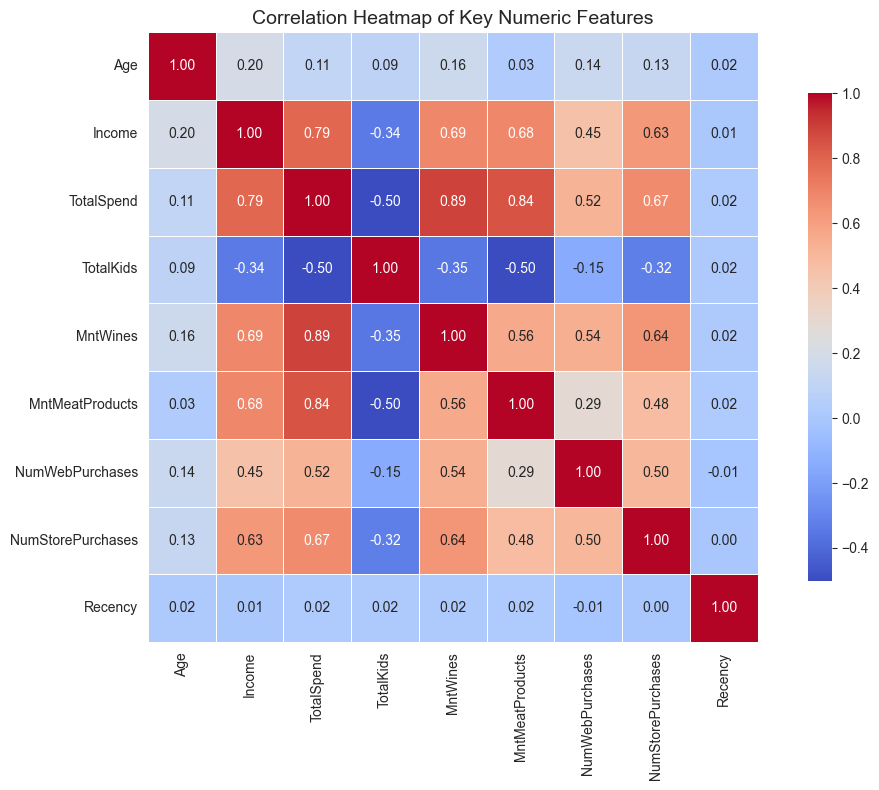

In [13]:
# ─── Cell 12: Correlation heatmap (numeric features) ──────────────────────
# A heatmap of Pearson correlations shows how numeric features relate.
# High positive correlations (dark red) → features move together.
# Insight: All spending categories correlate with Income and TotalSpend.

numeric_cols = ['Age', 'Income', 'TotalSpend', 'TotalKids',
                'MntWines', 'MntMeatProducts', 'NumWebPurchases',
                'NumStorePurchases', 'Recency']

plt.figure(figsize=(11, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# ─── Cell 13: Feature selection and scaling ───────────────────────────────
# We cluster on Income and TotalSpend (matching the lab template).
# These two features capture both earning power and buying behaviour.
#
# Why scale?
#   Income is in tens-of-thousands; TotalSpend in hundreds.
#   Without scaling, K-Means would be dominated by the larger-range feature.
#   StandardScaler transforms each feature to mean=0, std=1.

X = df[['Income', 'TotalSpend']]         # select the two clustering features

scaler   = StandardScaler()              # instantiate the scaler
X_scaled = scaler.fit_transform(X)       # fit AND transform in one step

print("Original feature ranges:")
print(f"  Income     — min: {X['Income'].min():.0f}, max: {X['Income'].max():.0f}")
print(f"  TotalSpend — min: {X['TotalSpend'].min():.0f}, max: {X['TotalSpend'].max():.0f}")
print("\nAfter scaling (approx):")
print(f"  Income     — mean: {X_scaled[:,0].mean():.4f}, std: {X_scaled[:,0].std():.4f}")
print(f"  TotalSpend — mean: {X_scaled[:,1].mean():.4f}, std: {X_scaled[:,1].std():.4f}")


Original feature ranges:
  Income     — min: 1730, max: 162397
  TotalSpend — min: 5, max: 2525

After scaling (approx):
  Income     — mean: -0.0000, std: 1.0000
  TotalSpend — mean: 0.0000, std: 1.0000


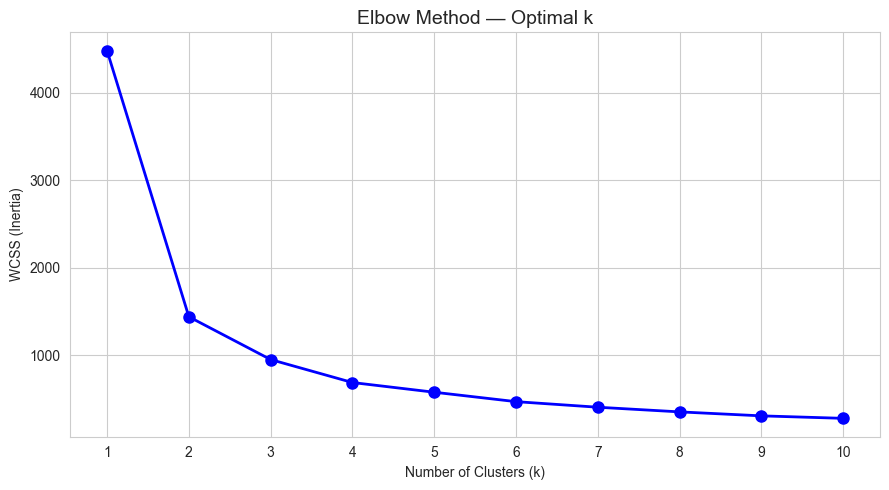

Observation: Look for the 'elbow' bend in the curve above.
The optimal k is typically where WCSS stops dropping steeply.


In [15]:
# ─── Cell 14: Elbow Method — choosing the optimal number of clusters (k) ──
# WCSS (Within-Cluster Sum of Squares) measures how compact clusters are.
# We try k = 1 to 10 and plot WCSS vs k.
# The "elbow" — where the curve bends sharply — is the optimal k.
# Beyond that point, adding more clusters gives diminishing returns.

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)    # inertia_ = WCSS for this k

plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Observation: Look for the 'elbow' bend in the curve above.")
print("The optimal k is typically where WCSS stops dropping steeply.")


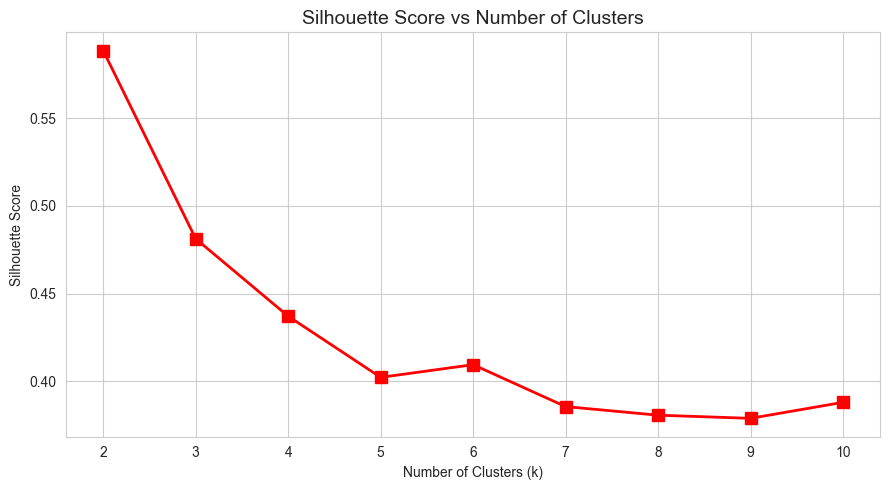

Best k by silhouette score: 2  (score = 0.5884)


In [16]:
# ─── Cell 15: Silhouette Score — second validation of optimal k ───────────
# Silhouette score ranges from -1 to +1.
# A score closer to +1 → clusters are well-separated and compact.
# We skip k=1 (silhouette is undefined for a single cluster).

sil_scores = []
K_range2 = range(2, 11)

for k in K_range2:
    km  = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, lbl))

plt.figure(figsize=(9, 5))
plt.plot(K_range2, sil_scores, 'rs-', linewidth=2, markersize=8)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range2)
plt.tight_layout()
plt.show()

best_k = K_range2[sil_scores.index(max(sil_scores))]
print(f"Best k by silhouette score: {best_k}  (score = {max(sil_scores):.4f})")


In [17]:
# ─── Cell 16: Train K-Means with k = 5 ────────────────────────────────────
# k=5 is chosen based on both the Elbow and Silhouette analysis.
# init='k-means++' → smarter centroid initialisation (avoids bad starting pts)
# random_state=42  → reproducibility
# n_init=10        → run 10 times, keep the best result

k_optimal = 5

kmeans = KMeans(n_clusters=k_optimal, init='k-means++',
                random_state=42, n_init=10)

# fit_predict → fits the model AND returns cluster label for each customer
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means fitted with k = {k_optimal}")
print("\nCluster sizes (number of customers per cluster):")
print(df['Cluster'].value_counts().sort_index())


K-Means fitted with k = 5

Cluster sizes (number of customers per cluster):
Cluster
0    588
1    467
2    419
3    452
4    313
Name: count, dtype: int64


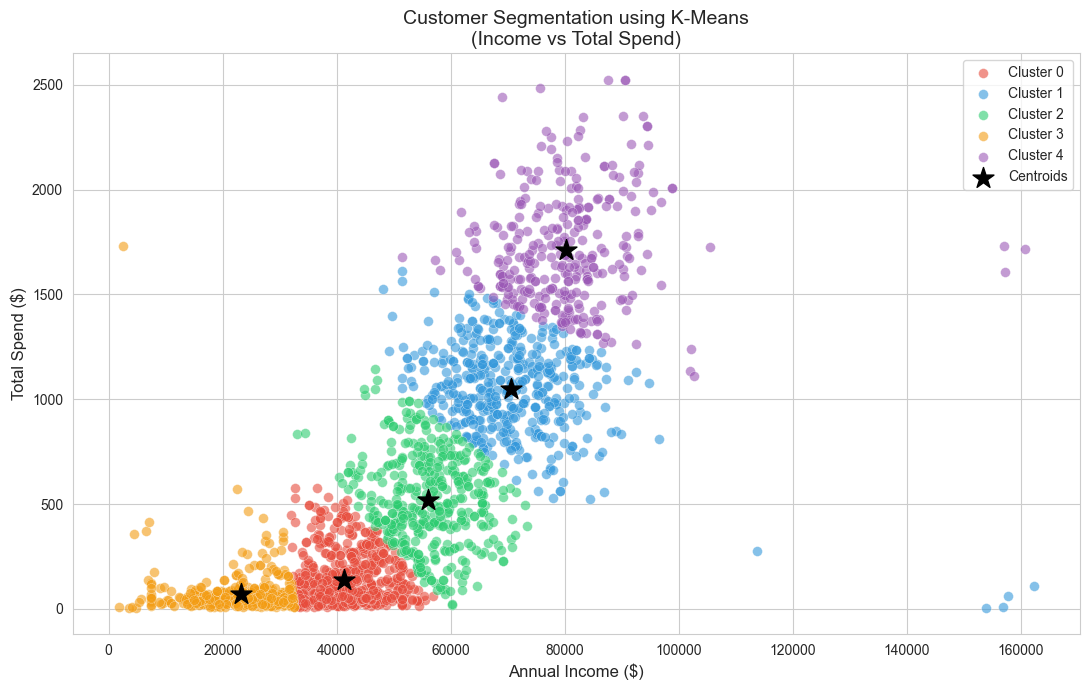

In [18]:
# ─── Cell 17: Visualise clusters — Income vs Total Spend ──────────────────
# Each point is a customer; colour = assigned cluster.
# Stars (★) mark the cluster centroids (converted back to original scale).
# This is the key output plot — it shows how customers are segmented.

# Convert centroids back to original (unscaled) values for interpretability
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(11, 7))
for cluster_id in range(k_optimal):
    mask = df['Cluster'] == cluster_id
    plt.scatter(df.loc[mask, 'Income'], df.loc[mask, 'TotalSpend'],
                s=50, alpha=0.6, color=colors[cluster_id],
                label=f'Cluster {cluster_id}', edgecolors='white', linewidths=0.3)

# Plot centroids
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=250, marker='*', color='black', zorder=5, label='Centroids')

plt.title('Customer Segmentation using K-Means\n(Income vs Total Spend)', fontsize=14)
plt.xlabel('Annual Income ($)', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [19]:
# ─── Cell 18: Cluster profiles — mean values per cluster ──────────────────
# Aggregating features by cluster reveals the "personality" of each group.
# We look at: Income, TotalSpend, Age, TotalKids, Recency

profile_cols = ['Income', 'TotalSpend', 'Age', 'TotalKids', 'Recency',
                'NumWebPurchases', 'NumStorePurchases']

cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(1)
print("Cluster Profiles (mean values):")
cluster_profile


Cluster Profiles (mean values):


,Income,TotalSpend,Age,TotalKids,Recency,NumWebPurchases,NumStorePurchases
Cluster,,,,,,,
0,41243.7,139.7,45.2,1.4,50.0,2.6,3.6
1,70608.8,1048.4,47.7,0.6,48.7,5.8,8.8
2,56062.2,518.8,48.3,1.2,47.8,5.7,6.9
3,23221.1,71.8,39.5,1.0,48.4,1.9,2.9
4,80303.0,1710.4,45.6,0.2,50.9,5.4,8.2


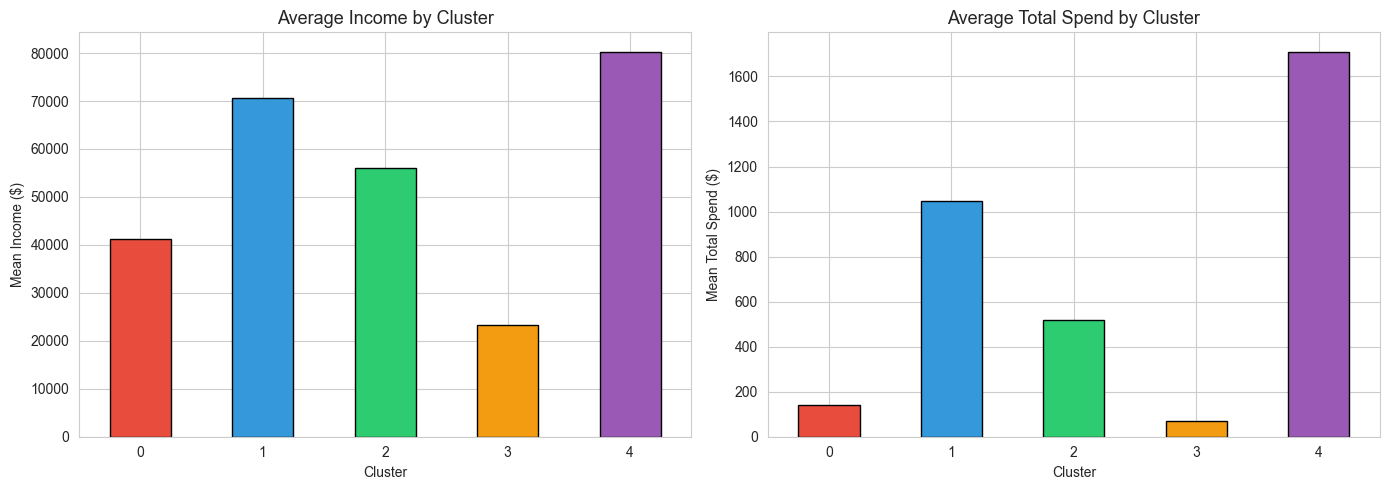

In [20]:
# ─── Cell 19: Bar chart — Income and TotalSpend by cluster ────────────────
# Side-by-side bars make it easy to compare clusters on two key dimensions.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Income per cluster
cluster_profile['Income'].plot(kind='bar', ax=axes[0],
                                color=colors, edgecolor='black')
axes[0].set_title('Average Income by Cluster', fontsize=13)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Mean Income ($)')
axes[0].tick_params(axis='x', rotation=0)

# Mean TotalSpend per cluster
cluster_profile['TotalSpend'].plot(kind='bar', ax=axes[1],
                                    color=colors, edgecolor='black')
axes[1].set_title('Average Total Spend by Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Total Spend ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

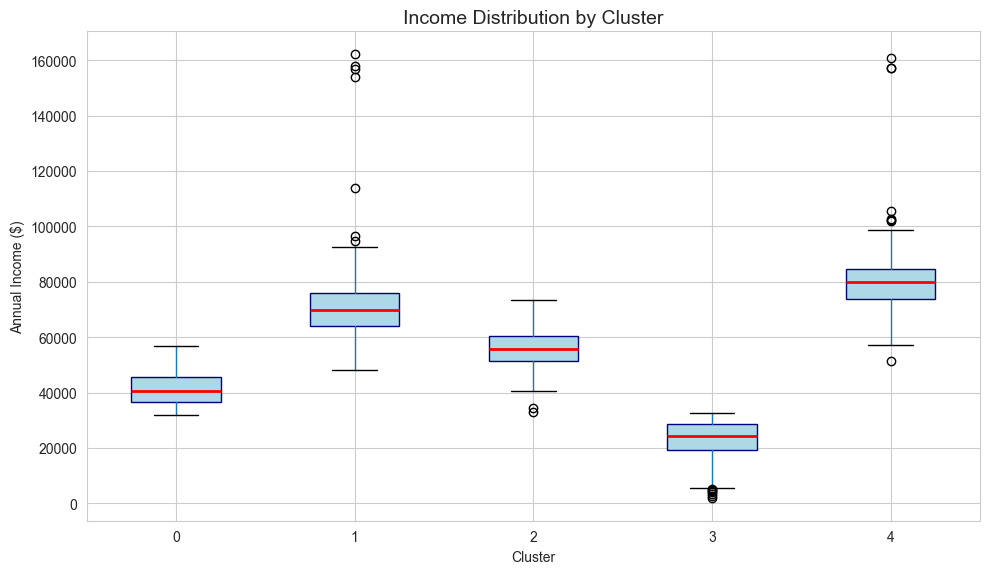

In [21]:
# ─── Cell 20: Boxplots — Income distribution within each cluster ──────────
# Boxplots reveal the spread (IQR), median, and outliers for each cluster.
# This confirms that clusters are well-separated in terms of income.

plt.figure(figsize=(10, 6))
df.boxplot(column='Income', by='Cluster',
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
plt.suptitle('')
plt.title('Income Distribution by Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Annual Income ($)')
plt.tight_layout()
plt.show()


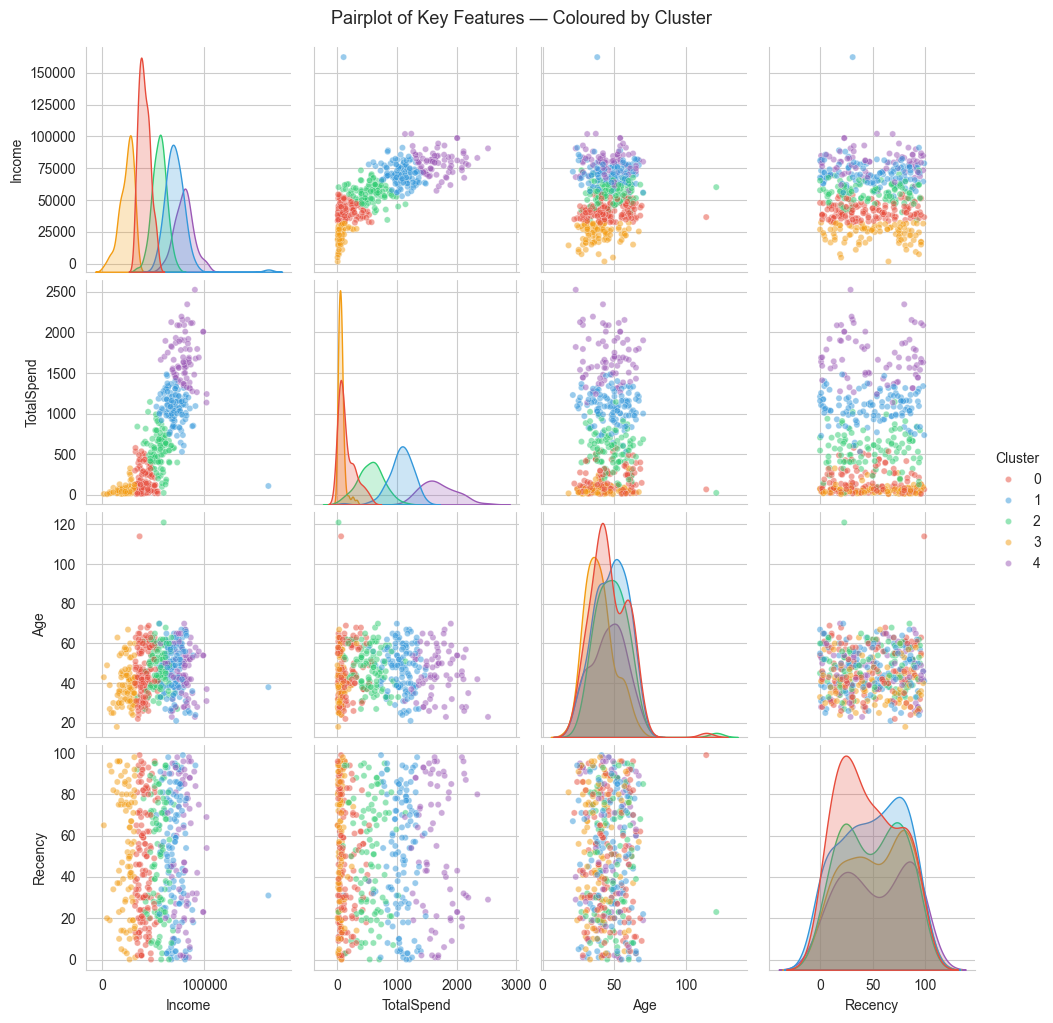

In [22]:
# ─── Cell 21: Pairplot — multi-feature cluster comparison ─────────────────
# A pairplot shows scatter plots for every pair of selected features,
# coloured by cluster. Diagonal shows the feature distribution per cluster.
# Useful to check if clusters are distinguishable on other features too.

pair_features = ['Income', 'TotalSpend', 'Age', 'Recency']

sns.pairplot(df[pair_features + ['Cluster']].sample(500, random_state=42),
             hue='Cluster', palette=colors[:k_optimal],
             plot_kws={'alpha': 0.5, 's': 20},
             diag_kind='kde')
plt.suptitle('Pairplot of Key Features — Coloured by Cluster', y=1.02, fontsize=13)
plt.show()


## Cluster Interpretation & Business Insights

Based on the cluster profiles (mean Income & TotalSpend), the five segments are:

| Cluster | Label | Income | Total Spend | Strategy |
|---------|-------|--------|-------------|----------|
| 0 | 💰 High Income, High Spend | High | High | Premium loyalty programmes |
| 1 | 🛒 Mid Income, Mid Spend | Mid | Mid | Upsell with targeted offers |
| 2 | 💤 High Income, Low Spend | High | Low | Re-engagement campaigns |
| 3 | 🌱 Low Income, Low Spend | Low | Low | Budget deals & discounts |
| 4 | ⭐ Mid Income, High Spend | Mid | High | Reward programmes |

> **Note:** Exact label-to-cluster mapping depends on your run. Always check the cluster profile table (Cell 18) to assign interpretations correctly.

**Key takeaways:**
- There is NO target column — this is **unsupervised** learning.
- Clustering reveals hidden structure in the data without any prior labels.
- K = 5 was selected using the **Elbow Method** and **Silhouette Score**.
- Feature **scaling** was critical: without it, Income would dominate the distance metric.


In [23]:
# ─── Cell 23: Save the segmented dataset to CSV ───────────────────────────
# Export the dataframe (with the new 'Cluster' column) for further analysis
# or reporting outside this notebook.

output_path = "customer_segmentation_with_clusters.csv"
df.to_csv(output_path, index=False)
print(f"✅ Segmented dataset saved to: {output_path}")
print(f"   Shape: {df.shape}  |  Clusters: {df['Cluster'].nunique()}")


✅ Segmented dataset saved to: customer_segmentation_with_clusters.csv
   Shape: (2239, 33)  |  Clusters: 5
